# Testing restoration model, collecting metrics, comparing 0 epoch and last (25) 

### Data preparing

In [1]:
!git clone https://github.com/RailSAB/real-esrganmodel.git

Cloning into 'real-esrganmodel'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 33 (delta 8), reused 10 (delta 3), pack-reused 15 (from 1)
Receiving objects: 100% (33/33), 59.24 MiB | 37.35 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [2]:
%cd /kaggle/working/real-esrganmodel

/kaggle/working/real-esrganmodel


In [3]:
!pip install -r requirements.txt

INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 25.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

### Imports

In [14]:
import os
import glob
from tqdm import tqdm
from PIL import Image
import numpy as np
import pandas as pd
from skimage import img_as_float
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
import torch
import cv2
import random
from skimage import util 


In [ ]:
# Paths and parameters
INPUT_DIR = '/kaggle/input/testlid'
OUT_BASE = '/kaggle/working/results_restoration'
OUT_E0 = os.path.join(OUT_BASE, 'epoch_0')
OUT_E20 = os.path.join(OUT_BASE, 'epoch_20')
OUT_DEG = os.path.join(OUT_BASE, 'degraded')
os.makedirs(OUT_E0, exist_ok=True)
os.makedirs(OUT_E20, exist_ok=True)
os.makedirs(OUT_DEG, exist_ok=True)
WEIGHT_EPOCH_0 = '/kaggle/input/checkpoints-for-readl-ersgan/checkpoint_epoch1.pth'
WEIGHT_EPOCH_20 = '/kaggle/input/checkpoints-for-readl-ersgan/checkpoint_epoch25.pth'
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

### Helper functions

In [ ]:
def list_images(input_dir):
    files = []
    for ext in IMG_EXTS:
        files.extend(glob.glob(os.path.join(input_dir, '**', f'*{ext}'), recursive=True))
    return sorted(files)

def resize_to(src, target_shape):
    target_h, target_w = target_shape[0], target_shape[1]
    img = Image.fromarray(src)
    img = img.resize((target_w, target_h), Image.BICUBIC)
    return np.array(img)

# Degradation utilities (resolution, dust/scratch, compression, noise)
def resolution_reduce(image, scale=0.5):
    height, width = image.shape[:2]
    smaller_image = cv2.resize(image, (int(width * scale), int(height * scale)), interpolation=cv2.INTER_AREA)
    restored_image = cv2.resize(smaller_image, (width, height), interpolation=cv2.INTER_CUBIC)
    return restored_image
    
def add_dust_and_scratch(image):
    num_scratches = random.randint(0, 3)
    num_dust = random.randint(10, 20)
    corrupted = image.copy()
    h, w = corrupted.shape[:2]
        
    for _ in range(num_scratches):
        scratch_type = random.choice(['random', 'edge_to_edge'])
        if scratch_type == 'random':
            pt1 = (random.randint(0, w), random.randint(0, h))
            pt2 = (random.randint(0, w), random.randint(0, h))
        else:
            center_x = random.randint(0, w-1)
            center_y = random.randint(0, h-1)
            
            angle = random.uniform(0, 2 * np.pi)
            
            dx = np.cos(angle)
            dy = np.sin(angle)
            
            intersections = []
            
            if dx != 0:
                t = (w - 1 - center_x) / dx
                y = center_y + t * dy
                if 0 <= y <= h - 1:
                    intersections.append((w - 1, int(y)))

            if dx != 0:
                t = (0 - center_x) / dx
                y = center_y + t * dy
                if 0 <= y <= h - 1:
                    intersections.append((0, int(y)))

            if dy != 0:
                t = (h - 1 - center_y) / dy
                x = center_x + t * dx
                if 0 <= x <= w - 1:
                    intersections.append((int(x), h - 1))
                
            if dy != 0:
                t = (0 - center_y) / dy
                x = center_x + t * dx
                if 0 <= x <= w - 1:
                    intersections.append((int(x), 0))

            if len(intersections) >= 2:
                intersections.sort(key=lambda p: (p[0] - center_x)**2 + (p[1] - center_y)**2)
                pt1 = intersections[0]
                pt2 = intersections[-1]
            else:
                pt1 = (random.randint(0, w-1), random.randint(0, h-1))
                pt2 = (random.randint(0, w-1), random.randint(0, h-1))
            
        gray_value = random.randint(110, 210)
        color = (gray_value, gray_value, gray_value)
        cv2.line(corrupted, pt1, pt2, color, 1)

    for _ in range(num_dust):
        center = (random.randint(0, w), random.randint(0, h))
        radius = random.randint(1, 2)
        gray_value = random.randint(110, 210)
        color = (gray_value, gray_value, gray_value)
        cv2.circle(corrupted, center, radius, color, -1)
        
    return corrupted

def compress_image(image, quality=20):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encimg = cv2.imencode('.jpg', image, encode_param)
    compressed = cv2.imdecode(encimg, 1)
    return compressed

    
def add_noise(image, noise_type='gaussian', a=0.05):
    if noise_type == 'gaussian':
        noise = np.random.normal(0, a * 255, image.shape).astype(np.uint8)
        noisy_image = cv2.add(image, noise)
    elif noise_type == 'salt_pepper':
        noisy_image = util.random_noise(image, mode='s&p', amount=a)
        noisy_image = (255 * noisy_image).astype(np.uint8)
    elif noise_type == 'speckle':
        noise = np.random.randn(*image.shape).astype(np.float32)
        noisy_image = image + image * noise * a
        noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    else:
        raise ValueError("Unsupported noise type")
    return noisy_image

def apply_degradation(img):
    img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    if random.random() < 0.4:
        combined_restoration = add_dust_and_scratch(img)
    else:
        combined_restoration = img.copy()

    n = random.random()
    if n < 0.5:
        combined_restoration = add_noise(combined_restoration, 'speckle', np.random.choice([0.05, 0.1, 0.15, 0.2, 0.25, 0.3]))
    elif n < 0.75:
        combined_restoration = add_noise(combined_restoration, 'salt_pepper', np.random.choice([0.005, 0.01, 0.015, 0.02]))
    else:
        combined_restoration = add_noise(combined_restoration, 'gaussian', np.random.choice([0.0015, 0.002, 0.001]))

    n = random.random()
    if n < 0.33:
        combined_restoration = resolution_reduce(combined_restoration, np.random.choice([0.3, 0.4, 0.5]))
    elif n < 0.66:
        combined_restoration = compress_image(combined_restoration, np.random.choice([20, 30]))

    combined_restoration = cv2.cvtColor(combined_restoration, cv2.COLOR_BGR2RGB)
    combined_restoration = Image.fromarray(combined_restoration)

    return combined_restoration

In [17]:
def ssim_safe(a, b):
    h, w = a.shape[:2]
    min_dim = min(h, w)
    if min_dim < 3:
        return float('nan')
    win = min(7, min_dim if (min_dim % 2 == 1) else (min_dim - 1))
    try:
        return float(ssim(a, b, data_range=1.0, channel_axis=-1, win_size=win))
    except TypeError:
        return float(ssim(a, b, data_range=1.0, multichannel=True, win_size=win))

### Model defining and inference run

In [18]:
real_esrgan_available = True
try:
    from RealESRGAN import RealESRGAN
except Exception as e:
    print('RealESRGAN import failed:', e)
    real_esrgan_available = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

files = list_images(INPUT_DIR)
print(f'Found {len(files)} image(s) in {INPUT_DIR}')

results = []

Found 30000 image(s) in /kaggle/input/testlid


In [ ]:
if real_esrgan_available:
    # Load models for epoch 0 and epoch 25
    models = {}
    for epoch, wp in [(0, WEIGHT_EPOCH_0), (20, WEIGHT_EPOCH_20)]:
        if os.path.isfile(wp):
            try:
                model = RealESRGAN(device, scale=4)
                model.load_weights(wp)
                models[epoch] = model
                print(f'Loaded RealESRGAN weights for epoch {epoch} from {wp}')
            except Exception as e:
                print(f'Failed to load weights for epoch {epoch}:', e)
        else:
            print(f'Weight file not found for epoch {epoch}: {wp}')

    # Iterate files and run per-file inference using both models
    for img_path in tqdm(files, desc='Images'):
        fname = os.path.basename(img_path)
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print('Failed to open', img_path, e)
            results.append({'file': fname, 'epoch': 'open_error', 'error': str(e)})
            continue
        gt = np.array(img)

        # Create degraded version per user's function and save it
        try:
            degraded = apply_degradation(img)
            degraded_name = os.path.splitext(fname)[0] + '_degraded.png'
            degraded_path = os.path.join(OUT_DEG, degraded_name)
            degraded.save(degraded_path)
        except Exception as e:
            print(f'Degradation failed for {fname}:', e)
            results.append({'file': fname, 'epoch': 'degradation_error', 'error': str(e)})
            continue

        for epoch in [0, 20]:
            if epoch not in models:
                results.append({'file': fname, 'epoch': epoch, 'error': 'model_not_loaded'})
                continue
            model = models[epoch]
            try:
                # Run model on degraded image
                sr = model.predict(degraded)
                out_dir = OUT_E0 if epoch == 0 else OUT_E20
                out_name = os.path.splitext(fname)[0] + f'_sr_epoch{epoch}.png'
                out_path = os.path.join(out_dir, out_name)
                sr.save(out_path)

                pred = np.array(sr.convert('RGB')) if isinstance(sr, Image.Image) else np.array(sr)

                if pred.shape[:2] != gt.shape[:2]:
                    pred = resize_to(pred, gt.shape)
                gt_f = img_as_float(gt)
                pred_f = img_as_float(pred)
                mse_v = float(mse(gt_f, pred_f))
                psnr_v = float(psnr(gt_f, pred_f, data_range=1.0))
                ssim_v = float(ssim_safe(gt_f, pred_f))
                results.append({'file': fname, 'epoch': epoch, 'mse': mse_v, 'psnr': psnr_v, 'ssim': ssim_v, 'out_path': out_path, 'degraded_path': degraded_path})
            except Exception as e:
                print(f'Inference/metric error for {fname} epoch {epoch}:', e)
                results.append({'file': fname, 'epoch': epoch, 'error': str(e)})


    del models


Loaded RealESRGAN weights for epoch 0 from /kaggle/input/checkpoints-for-readl-ersgan/checkpoint_epoch1.pth
Loaded RealESRGAN weights for epoch 20 from /kaggle/input/checkpoints-for-readl-ersgan/checkpoint_epoch25.pth


Images: 100%|██████████| 300/300 [32:51<00:00,  6.57s/it]


### Single image comparison

Random file: nature_117316.jpg
Epoch 0 metrics: {'mse': 0.00157980993560044, 'psnr': 28.01395159175387, 'ssim': 0.7947559841385056}
Epoch 20 metrics: {'mse': 0.0015184569905755398, 'psnr': 28.185975047139365, 'ssim': 0.8112545670976962}


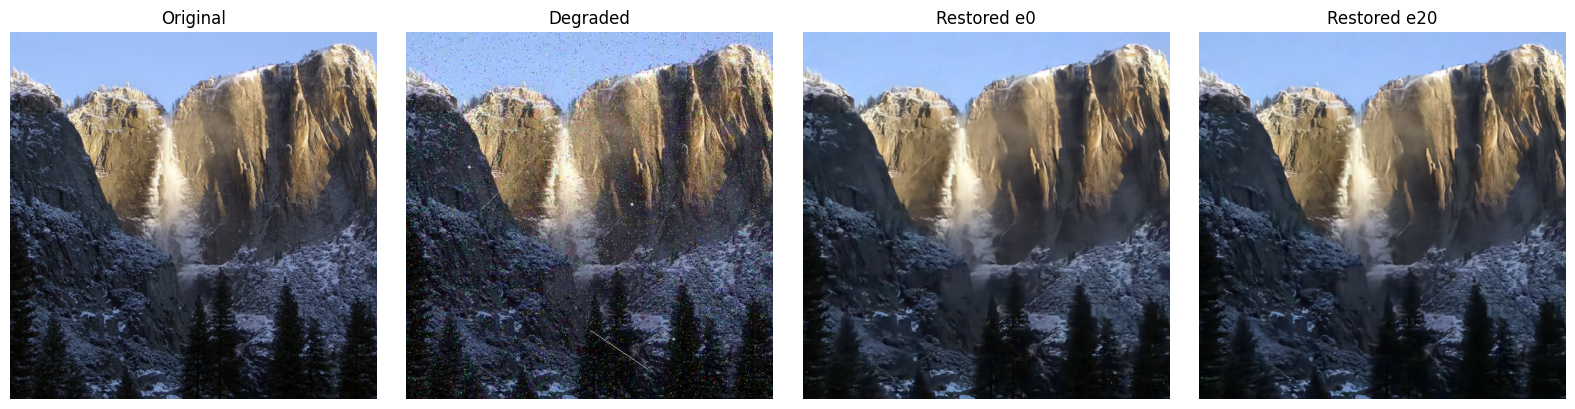

In [ ]:
import matplotlib.pyplot as plt

assert len(files) > 0, "No images found."

# Pick random image
rand_path = random.choice(files)
orig_img = Image.open(rand_path).convert('RGB')
orig_arr = np.array(orig_img)

# Degrade
deg_img = apply_degradation(orig_img)
deg_arr = np.array(deg_img)

# Ensure models loaded
if 'models' not in globals():
    models = {}
    for epoch, wp in [(0, WEIGHT_EPOCH_0), (20, WEIGHT_EPOCH_20)]:
        if os.path.isfile(wp):
            m = RealESRGAN(device, scale=4)
            m.load_weights(wp)
            models[epoch] = m
        else:
            print(f'Missing weight for epoch {epoch}: {wp}')

# Predict both epochs
restored = {}
for epoch in [0, 20]:
    if epoch in models:
        with torch.no_grad():
            restored_img = models[epoch].predict(deg_img)
        restored[epoch] = np.array(restored_img.convert('RGB'))
    else:
        restored[epoch] = None

# Resize restored to original size if needed
for epoch in [0, 20]:
    if restored[epoch] is not None and restored[epoch].shape[:2] != orig_arr.shape[:2]:
        restored[epoch] = resize_to(restored[epoch], orig_arr.shape)

# Metrics
def compute_metrics(gt, pred):
    if pred is None:
        return {'mse': None, 'psnr': None, 'ssim': None}
    gt_f = img_as_float(gt)
    pred_f = img_as_float(pred)
    return {
        'mse': float(mse(gt_f, pred_f)),
        'psnr': float(psnr(gt_f, pred_f, data_range=1.0)),
        'ssim': float(ssim_safe(gt_f, pred_f))
    }

metrics_e0 = compute_metrics(orig_arr, restored[0])
metrics_e20 = compute_metrics(orig_arr, restored[20])

print(f'Random file: {os.path.basename(rand_path)}')
print('Epoch 0 metrics:', metrics_e0)
print('Epoch 20 metrics:', metrics_e20)

# Display
fig, axs = plt.subplots(1, 4, figsize=(16,4))
axs[0].imshow(orig_arr); axs[0].set_title('Original'); axs[0].axis('off')
axs[1].imshow(deg_arr); axs[1].set_title('Degraded'); axs[1].axis('off')
axs[2].imshow(restored[0] if restored[0] is not None else np.zeros_like(orig_arr)); axs[2].set_title('Restored e0'); axs[2].axis('off')
axs[3].imshow(restored[20] if restored[20] is not None else np.zeros_like(orig_arr)); axs[3].set_title('Restored e20'); axs[3].axis('off')
plt.tight_layout(); plt.show()